In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Read data and preview
df = pd.read_csv("../data/raw_weather.csv", index_col="date", parse_dates=True)
print(df.shape)
df.head()

(730, 5)


,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,et0_fao_evapotranspiration
date,,,,,
2024-03-20,32.6,27.6,0.7,17.9,4.35
2024-03-21,33.2,27.4,13.7,15.4,3.87
2024-03-22,33.2,27.4,0.0,18.8,4.79
2024-03-23,32.7,28.0,1.6,20.2,4.01
2024-03-24,32.5,27.0,0.0,15.6,4.82


In [2]:
# Check for missing values

print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDate range: {df.index.min()} → {df.index.max()}")
print(f"Total days: {len(df)}")

Missing values per column:
temperature_2m_max            0
temperature_2m_min            0
precipitation_sum             0
windspeed_10m_max             0
et0_fao_evapotranspiration    0
dtype: int64

Date range: 2024-03-20 00:00:00 → 2026-03-19 00:00:00
Total days: 730


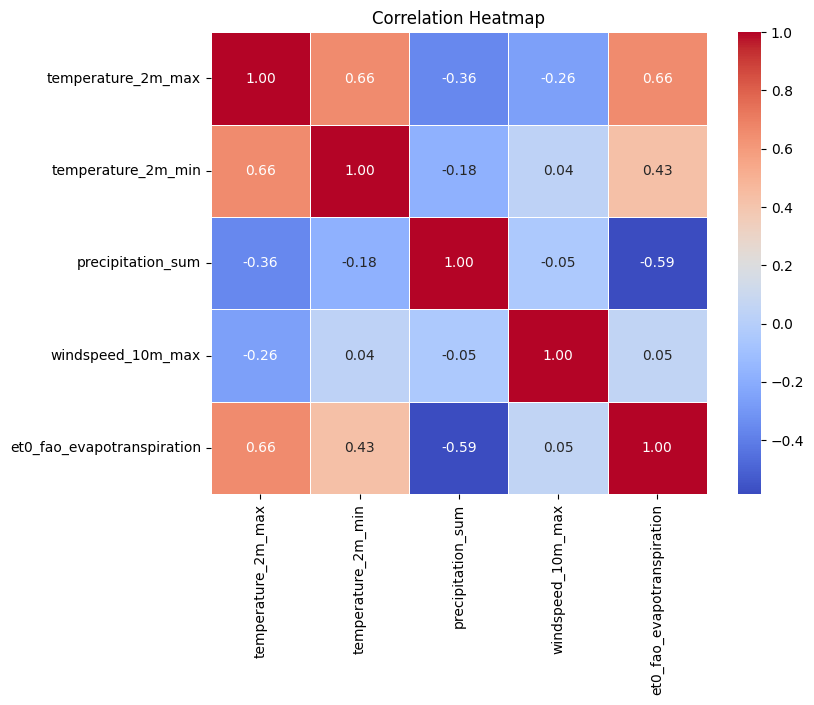

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

matrix = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

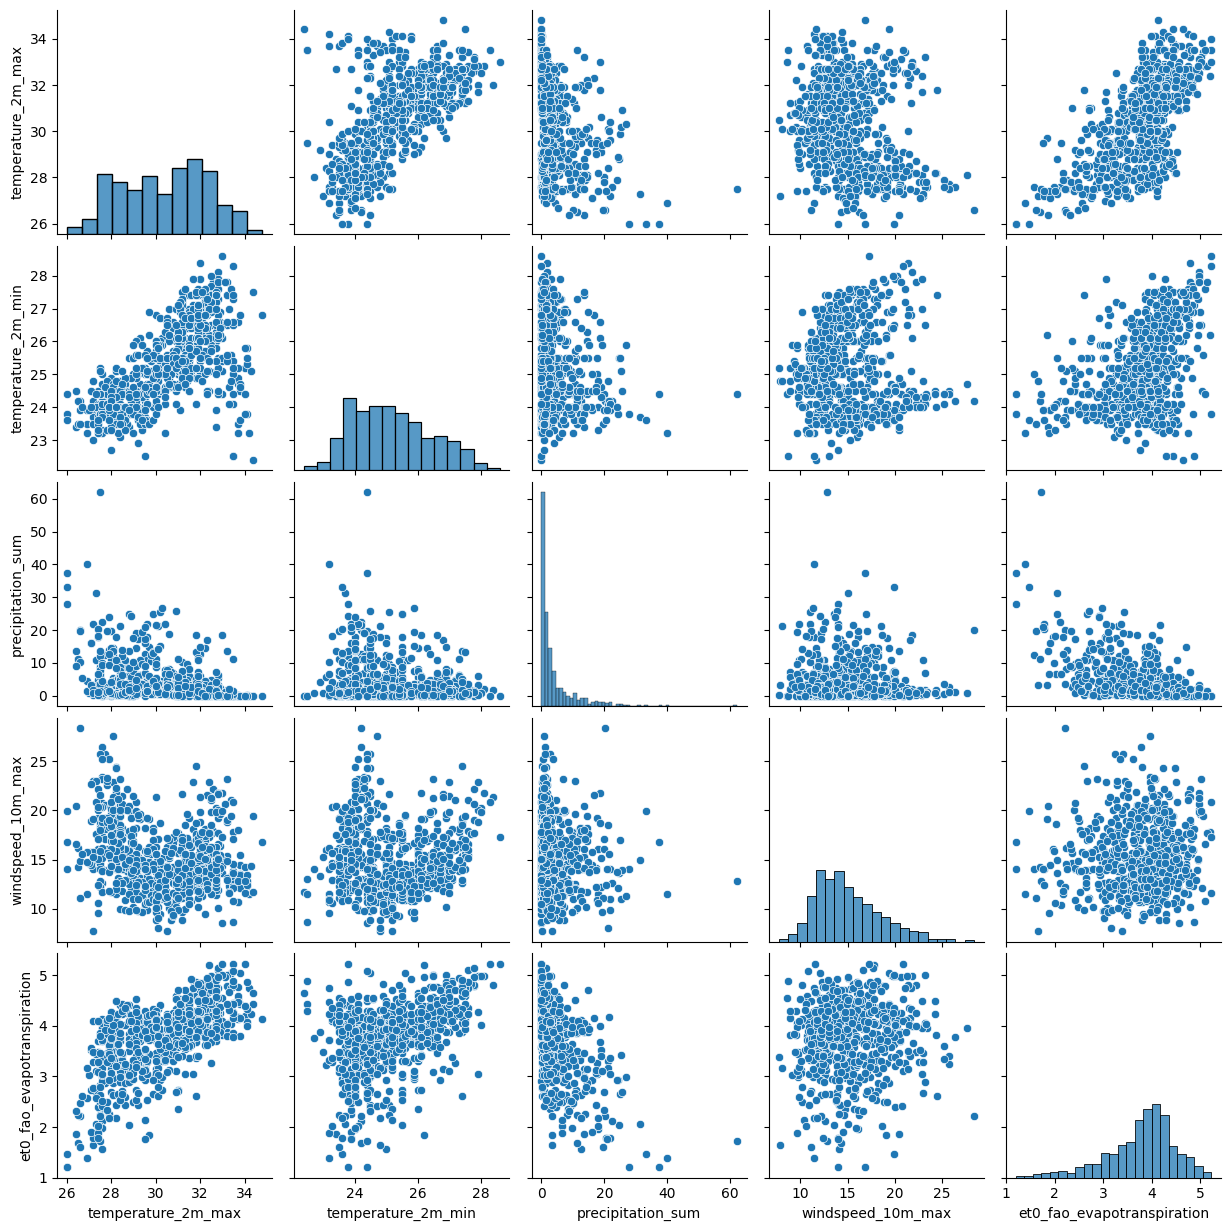

In [7]:
sns.pairplot(df)
plt.show()

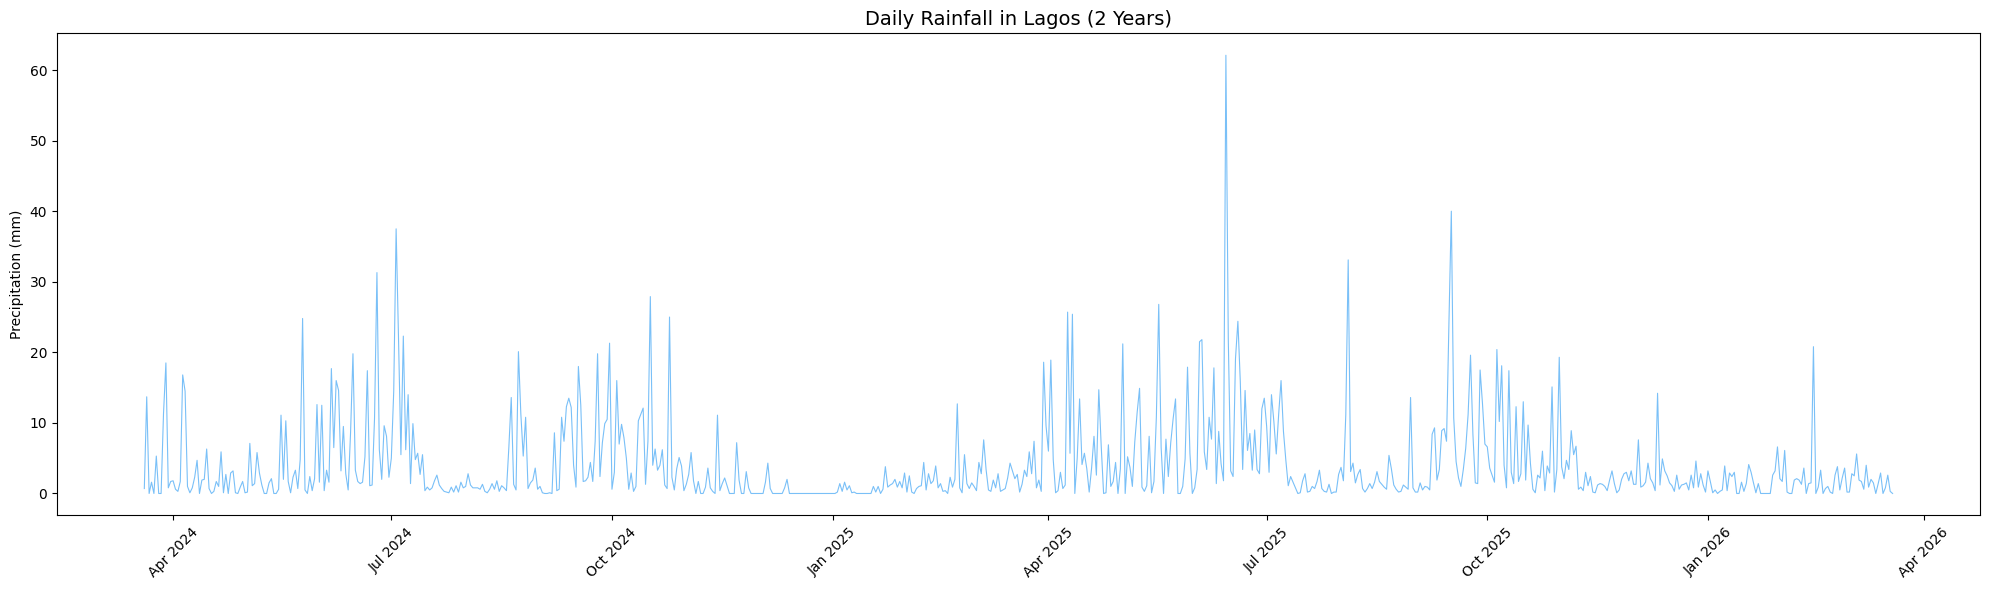

In [9]:
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(df.index, df["precipitation_sum"], color="#2196F3", alpha=0.6, linewidth=0.8)
ax.set_title("Daily Rainfall in Lagos (2 Years)", fontsize=14)
ax.set_ylabel("Precipitation (mm)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

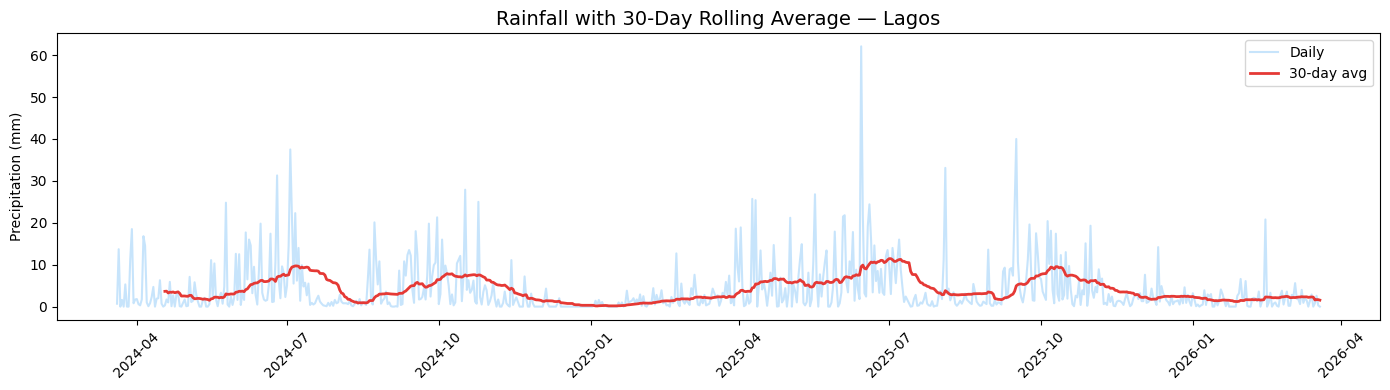

In [11]:
df["rolling_30d"] = df["precipitation_sum"].rolling(30).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["precipitation_sum"], color="#90CAF9", alpha=0.5, label="Daily")
ax.plot(df.index, df["rolling_30d"], color="#E53935", linewidth=2, label="30-day avg")
ax.set_title("Rainfall with 30-Day Rolling Average — Lagos", fontsize=14)
ax.set_ylabel("Precipitation (mm)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

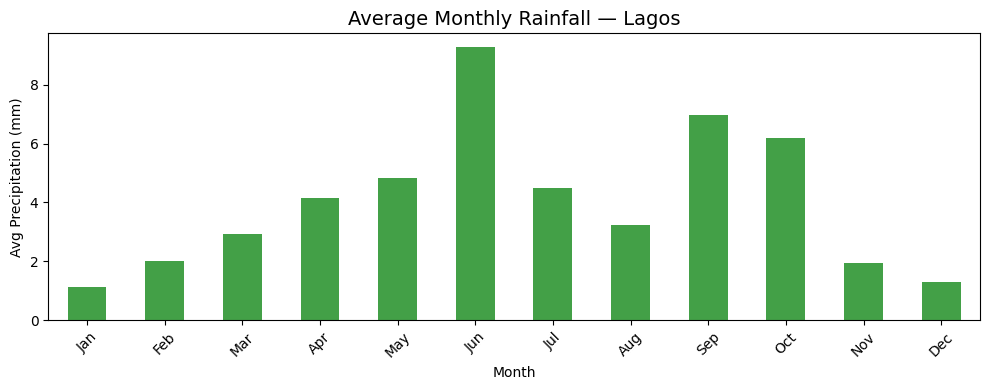

In [12]:
df["month"] = df.index.month
monthly_avg = df.groupby("month")["precipitation_sum"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
monthly_avg.plot(kind="bar", ax=ax, color="#43A047")
ax.set_title("Average Monthly Rainfall — Lagos", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Avg Precipitation (mm)")
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=45)
plt.tight_layout()
plt.show()